In [4]:
import pandas as pd
file_path = '/content/titagarh.csv'
df = pd.read_csv(file_path)

# Select only 'date' and 'pm2_5' columns
df_selected = df[['date_timestamp', 'pm2_5']]

# Define the output file path
output_file_path = 'indore_air_quality_date_pm2_5.csv'

# Save the selected columns to a new CSV file
df_selected.to_csv(output_file_path, index=False)

print(f"New CSV file '{output_file_path}' created successfully with 'date' and 'pm2_5' columns.")

# Display the first few rows of the new DataFrame to confirm
print("First 5 rows of the new DataFrame:")
display(df_selected.head())

New CSV file 'indore_air_quality_date_pm2_5.csv' created successfully with 'date' and 'pm2_5' columns.
First 5 rows of the new DataFrame:


,date_timestamp,pm2_5
0,2025-11-13T00:00,142.0
1,2025-11-13T01:00,136.9
2,2025-11-13T02:00,132.2
3,2025-11-13T03:00,119.7
4,2025-11-13T04:00,102.4


# Task
Perform a 72-hour time series forecast of PM2.5 values using a Random Forest model based on the `indore_air_quality_date_pm2_5.csv` dataset, and visualize the actual PM2.5 data against the forecasted values.

## Prepare Data for Forecasting

### Subtask:
Convert the 'date_timestamp' column to a datetime object, create numerical features (e.g., timestamp, hour, day of week, lag features) suitable for a Random Forest model, and handle any missing values if present.


**Reasoning**:
The 'date_timestamp' column needs to be converted to datetime objects, set as the DataFrame's index, and then used to extract numerical features like timestamp, hour, and day of the week. This is a crucial step for preparing time-series data for machine learning models.



**Reasoning**:
The previous code failed because it could not find the CSV file. Since the `df_selected` DataFrame already contains the necessary data from the last successful step, I will use it directly instead of re-reading the file. I will also add the new requirement of generating lag features and dropping missing values.



In [7]:
df = df_selected.copy()
df['date_timestamp'] = pd.to_datetime(df['date_timestamp'])
df = df.set_index('date_timestamp')

# Create numerical features
df['timestamp'] = df.index.map(pd.Timestamp.timestamp) # Convert datetime to Unix timestamp
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Generate lag features for 'pm2_5'
lags = [1, 2, 3, 24, 48, 72]
for lag in lags:
    df[f'pm2_5_lag_{lag}h'] = df['pm2_5'].shift(lag)

# Drop rows with missing values introduced by lag features
df.dropna(inplace=True)

print("DataFrame with datetime index, new features, and lag features:")
display(df.head())

DataFrame with datetime index, new features, and lag features:


,pm2_5,timestamp,hour,dayofweek,pm2_5_lag_1h,pm2_5_lag_2h,pm2_5_lag_3h,pm2_5_lag_24h,pm2_5_lag_48h,pm2_5_lag_72h
date_timestamp,,,,,,,,,,
2025-11-16 00:00:00,92.0,1.763251e+09,0,6,91.3,92.9,95.0,111.8,130.4,142.0
2025-11-16 01:00:00,95.0,1.763255e+09,1,6,92.0,91.3,92.9,115.5,129.0,136.9
2025-11-16 02:00:00,93.8,1.763258e+09,2,6,95.0,92.0,91.3,114.1,123.4,132.2
2025-11-16 03:00:00,88.2,1.763262e+09,3,6,93.8,95.0,92.0,106.2,111.8,119.7
2025-11-16 04:00:00,77.3,1.763266e+09,4,6,88.2,93.8,95.0,91.7,93.4,102.4


## Split Data and Train Random Forest Model

### Subtask:
Split the prepared data into training and testing sets, then train a Random Forest Regressor model using the training data.


**Reasoning**:
To prepare for model training, I will first separate the features (X) from the target variable (y), 'pm2_5', and then split the data into training and testing sets while preserving the chronological order. Finally, I will train a RandomForestRegressor model using the training data.



In [8]:
from sklearn.ensemble import RandomForestRegressor

# Separate features (X) and target (y)
X = df.drop('pm2_5', axis=1)
y = df['pm2_5']

# Determine the split point (e.g., 80% for training, 20% for testing)
split_point = int(len(df) * 0.8)

# Split data into training and testing sets, maintaining chronological order
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Initialize the Random Forest Regressor model
# Using a random_state for reproducibility
model = RandomForestRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Random Forest Regressor model trained successfully.
X_train shape: (2342, 9)
X_test shape: (586, 9)
y_train shape: (2342,)
y_test shape: (586,)


## Generate Future Dates and Forecast

### Subtask:
Create a DataFrame with future timestamps for the next 72 hours and use the trained Random Forest model to predict the 'pm2_5' values for these future dates.


**Reasoning**:
I need to generate a 72-hour forecast using the trained Random Forest model. This involves getting the last timestamp, generating future timestamps, creating basic features for these future timestamps, preparing a buffer for lag features, and then iteratively predicting each hour while updating the lag features based on previous predictions.



In [10]:
import numpy as np

# 1. Get the last timestamp from the df DataFrame's index
last_timestamp_df = df.index[-1]

# 2. Generate a pd.DatetimeIndex for the next 72 hours
future_dates = pd.date_range(start=last_timestamp_df + pd.Timedelta(hours=1), periods=72, freq='H')

# 3. Create an empty DataFrame, named future_df, with the generated DatetimeIndex
future_df = pd.DataFrame(index=future_dates)

# 4. Populate the basic features in future_df
future_df['timestamp'] = future_df.index.map(pd.Timestamp.timestamp)
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek

# 5. Prepare a temporary buffer for lag features
# We need the last 'max_lag' pm2_5 values from the original df
max_lag = max(lags)
lag_buffer = df['pm2_5'].iloc[-max_lag:].tolist()

# 6. Initialize an empty list called forecast_pm2_5_values to store the 72-hour predictions
forecast_pm2_5_values = []

# Get the feature columns order from X_train
feature_columns = X_train.columns.tolist()

# 7. Loop 72 times, for each hour of the forecast
for i in range(72):
    current_future_hour = future_df.iloc[i]

    # Construct features for the current future hour
    features_for_prediction = {
        'timestamp': current_future_hour['timestamp'],
        'hour': current_future_hour['hour'],
        'dayofweek': current_future_hour['dayofweek']
    }

    # Add lag features from the lag_buffer
    for lag_idx, lag_value in enumerate(lags):
        if lag_value <= len(lag_buffer):
            # lag_buffer[-lag_value] gives the value corresponding to pm2_5_lag_lag_value_h
            features_for_prediction[f'pm2_5_lag_{lag_value}h'] = lag_buffer[-lag_value]
        else:
            # If buffer is not long enough for a specific lag, fill with NaN or an appropriate value
            # For the purpose of this task, the buffer should be sufficiently populated from df
            features_for_prediction[f'pm2_5_lag_{lag_value}h'] = np.nan # This shouldn't happen with correct buffer size

    # Convert to DataFrame with single row, ensuring column order matches X_train
    current_X_predict = pd.DataFrame([features_for_prediction], index=[future_df.index[i]])
    current_X_predict = current_X_predict[feature_columns] # Reorder columns to match training data

    # Use the trained model to predict the 'pm2_5' value
    predicted_pm2_5 = model.predict(current_X_predict)[0]

    # Append this predicted value to the forecast_pm2_5_values list
    forecast_pm2_5_values.append(predicted_pm2_5)

    # Update the temporary lag buffer by appending the new predicted 'pm2_5' value
    # and removing the oldest value, effectively shifting the window
    lag_buffer.append(predicted_pm2_5)
    lag_buffer.pop(0)

# 8. Convert the forecast_pm2_5_values list into a pd.Series
forecast_pm2_5 = pd.Series(forecast_pm2_5_values, index=future_df.index, name='predicted_pm2_5')

print("72-hour PM2.5 forecast generated successfully.")
print("First 5 forecasted values:")
print(forecast_pm2_5.head())


/tmp/ipython-input-2649308139.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=last_timestamp_df + pd.Timedelta(hours=1), periods=72, freq='H')


72-hour PM2.5 forecast generated successfully.
First 5 forecasted values:
2025-11-18 00:00:00    73.978
2025-11-18 01:00:00    74.153
2025-11-18 02:00:00    74.120
2025-11-18 03:00:00    71.358
2025-11-18 04:00:00    70.729
Freq: h, Name: predicted_pm2_5, dtype: float64


**Reasoning**:
The previous code generated a `FutureWarning` about using 'H' for frequency instead of 'h'. I will correct this in the `pd.date_range` call. Additionally, the overall task requires visualizing the actual PM2.5 data against the forecasted values, so I will now add a step to plot the actual data and the generated forecast.



72-hour PM2.5 forecast generated successfully.
First 5 forecasted values:
2025-11-18 00:00:00    73.978
2025-11-18 01:00:00    74.153
2025-11-18 02:00:00    74.120
2025-11-18 03:00:00    71.358
2025-11-18 04:00:00    70.729
Freq: h, Name: predicted_pm2_5, dtype: float64


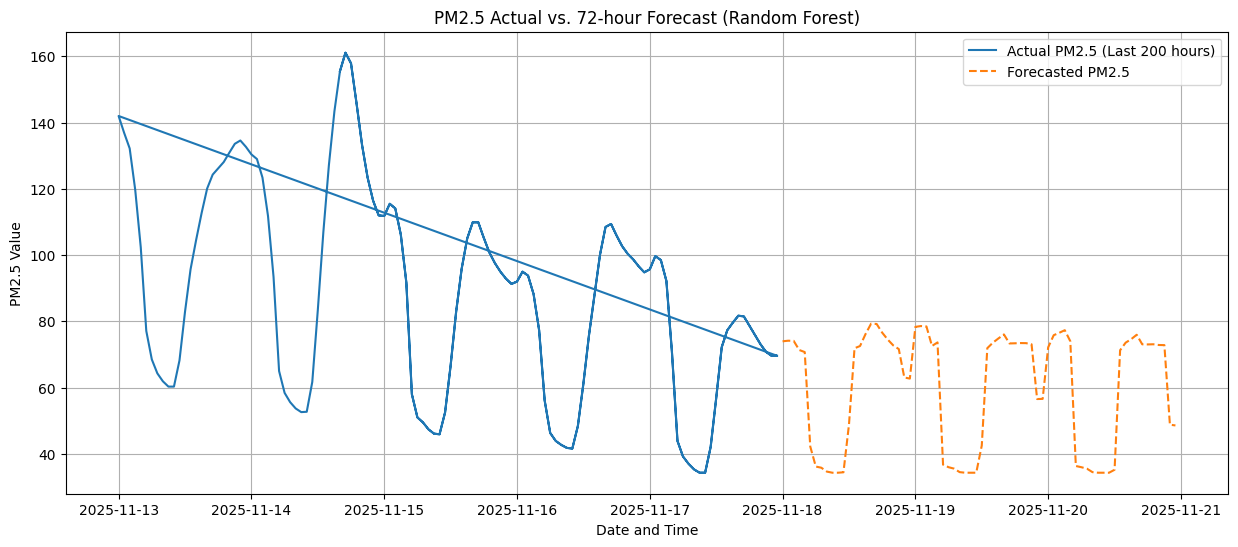

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get the last timestamp from the df DataFrame's index
last_timestamp_df = df.index[-1]

# 2. Generate a pd.DatetimeIndex for the next 72 hours
future_dates = pd.date_range(start=last_timestamp_df + pd.Timedelta(hours=1), periods=72, freq='h') # Corrected 'H' to 'h'

# 3. Create an empty DataFrame, named future_df, with the generated DatetimeIndex
future_df = pd.DataFrame(index=future_dates)

# 4. Populate the basic features in future_df
future_df['timestamp'] = future_df.index.map(pd.Timestamp.timestamp)
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek

# 5. Prepare a temporary buffer for lag features
# We need the last 'max_lag' pm2_5 values from the original df
max_lag = max(lags)
lag_buffer = df['pm2_5'].iloc[-max_lag:].tolist()

# 6. Initialize an empty list called forecast_pm2_5_values to store the 72-hour predictions
forecast_pm2_5_values = []

# Get the feature columns order from X_train
feature_columns = X_train.columns.tolist()

# 7. Loop 72 times, for each hour of the forecast
for i in range(72):
    current_future_hour = future_df.iloc[i]

    # Construct features for the current future hour
    features_for_prediction = {
        'timestamp': current_future_hour['timestamp'],
        'hour': current_future_hour['hour'],
        'dayofweek': current_future_hour['dayofweek']
    }

    # Add lag features from the lag_buffer
    for lag_idx, lag_value in enumerate(lags):
        if lag_value <= len(lag_buffer):
            # lag_buffer[-lag_value] gives the value corresponding to pm2_5_lag_lag_value_h
            features_for_prediction[f'pm2_5_lag_{lag_value}h'] = lag_buffer[-lag_value]
        else:
            # If buffer is not long enough for a specific lag, fill with NaN or an appropriate value
            # For the purpose of this task, the buffer should be sufficiently populated from df
            features_for_prediction[f'pm2_5_lag_{lag_value}h'] = np.nan # This shouldn't happen with correct buffer size

    # Convert to DataFrame with single row, ensuring column order matches X_train
    current_X_predict = pd.DataFrame([features_for_prediction], index=[future_df.index[i]])
    current_X_predict = current_X_predict[feature_columns] # Reorder columns to match training data

    # Use the trained model to predict the 'pm2_5' value
    predicted_pm2_5 = model.predict(current_X_predict)[0]

    # Append this predicted value to the forecast_pm2_5_values list
    forecast_pm2_5_values.append(predicted_pm2_5)

    # Update the temporary lag buffer by appending the new predicted 'pm2_5' value
    # and removing the oldest value, effectively shifting the window
    lag_buffer.append(predicted_pm2_5)
    lag_buffer.pop(0)

# 8. Convert the forecast_pm2_5_values list into a pd.Series
forecast_pm2_5 = pd.Series(forecast_pm2_5_values, index=future_df.index, name='predicted_pm2_5')

print("72-hour PM2.5 forecast generated successfully.")
print("First 5 forecasted values:")
print(forecast_pm2_5.head())

# Visualize actual vs. forecasted PM2.5
plt.figure(figsize=(15, 6))
plt.plot(df['pm2_5'].tail(200), label='Actual PM2.5 (Last 200 hours)') # Plot last few actual values
plt.plot(forecast_pm2_5, label='Forecasted PM2.5', linestyle='--')
plt.title('PM2.5 Actual vs. 72-hour Forecast (Random Forest)')
plt.xlabel('Date and Time')
plt.ylabel('PM2.5 Value')
plt.legend()
plt.grid(True)
plt.show()